# Solving PDEs: Classical Numerical Methods vs. Physics-Informed Neural Networks (PINNs)

**What problem are we solving?** Partial Differential Equations (PDEs) describe how a quantity changes across both space *and* time — heat spreading through a rod, fluid flowing through a pipe, stresses propagating through a material. This is the natural follow-up to the ODE project: an ODE only tracks a variable through time, while a PDE tracks it through time *and* space at once, which is why PDEs are harder and why entire numerical-methods subfields exist just to solve them well.

**Two approaches, side by side (same philosophy as the ODE notebook):**
1. **Classical numerical methods — the Method of Lines.** We discretize space into a grid, turn spatial derivatives into finite-difference approximations, and this collapses the PDE into a large system of ODEs — one per grid point — which we then hand to a standard ODE solver (`solve_ivp`). This is a real, widely-used industrial technique, not a toy simplification.
2. **Physics-Informed Neural Networks (PINNs).** A single neural network $\hat{u}_\theta(x, t)$ takes space *and* time as input and is trained so that its automatic derivatives satisfy the PDE everywhere, plus the initial and boundary conditions. This is the same core idea as the ODE notebook, extended to two input dimensions.

**Two examples, increasing difficulty — deliberately mirroring the ODE notebook's structure:**
- **Part A — 1D Heat Equation** (linear, has an exact solution) — used to confirm both methods are actually correct.
- **Part B — Viscous Burgers' Equation** (nonlinear, develops a steep near-shock front) — the exact benchmark PDE used in the original 2019 PINN paper (Raissi, Perdikaris & Karniadakis), included here because it's a well-known, honest stress test for both classical grid methods and PINNs.

**How this notebook is organized:** every section opens with a short explanation of *what we're about to do and what to expect*, then the code, so it reads as a narrative even before running anything.

**Run this in Google Colab** — PyTorch and SciPy are installed/available automatically in the first cell.


## 1. Environment Setup

**What we do here:** import `scipy.integrate.solve_ivp` (used for the Method-of-Lines classical solver) and `torch` (used for the PINN).

**What to expect:** just install/import logs.


In [1]:
!pip install -q torch --upgrade

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

import torch
import torch.nn as nn

torch.manual_seed(42)
np.random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
print("torch:", torch.__version__)


error: externally-managed-environment

× This environment is externally managed
╰─> To install Python packages system-wide, try apt install
    python3-xyz, where xyz is the package you are trying to
    install.
    
    If you wish to install a non-Debian-packaged Python package,
    create a virtual environment using python3 -m venv path/to/venv.
    Then use path/to/venv/bin/python and path/to/venv/bin/pip. Make
    sure you have python3-full installed.
    
    If you wish to install a non-Debian packaged Python application,
    it may be easiest to use pipx install xyz, which will manage a
    virtual environment for you. Make sure you have pipx installed.
    
    See /usr/share/doc/python3.12/README.venv for more information.

note: If you believe this is a mistake, please contact your Python installation or OS distribution provider. You can override this, at the risk of breaking your Python installation or OS, by passing --break-system-packages.
hint: See PEP 668 for the detai

Using device: cpu
torch: 2.14.0+cu130


---
# Part A — 1D Heat Equation (Linear PDE)

## 2. The Problem

**What we're solving:** heat spreading along a thin rod of length 1, with both ends held at a fixed temperature of 0:

$$\frac{\partial u}{\partial t} = \alpha \frac{\partial^2 u}{\partial x^2}, \qquad x \in [0, 1],\ t \in [0, 1]$$
$$u(0, t) = u(1, t) = 0 \quad \text{(ends held at 0)}, \qquad u(x, 0) = \sin(\pi x) \quad \text{(initial heat profile)}$$

With $\alpha = 0.5$, this equation has a known **exact closed-form solution**:

$$u(x, t) = e^{-\alpha \pi^2 t}\sin(\pi x)$$

**Why this example first:** just like Part A of the ODE notebook, having an exact answer lets us validate both numerical methods against ground truth rather than just against each other.

**What to expect / predict:** the initial sine-shaped heat bump should smoothly flatten out and decay toward zero everywhere as $t$ increases — heat spreading out and dissipating, exactly like a real rod cooling down.


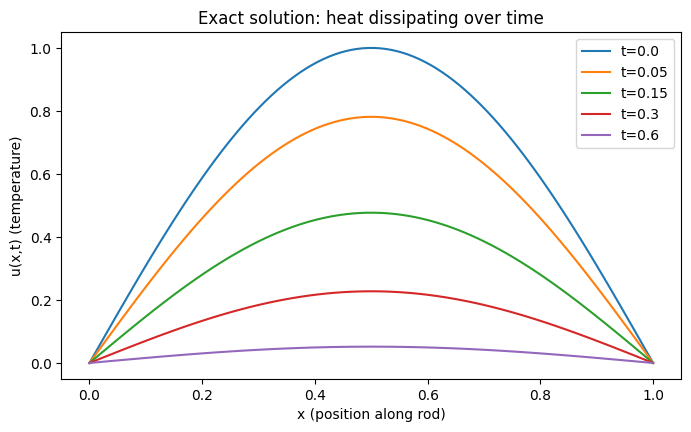

In [2]:
alpha = 0.5

def exact_heat(x, t):
    return np.exp(-alpha * np.pi**2 * t) * np.sin(np.pi * x)

x_plot = np.linspace(0, 1, 100)
plt.figure(figsize=(8, 4.5))
for t_snap in [0.0, 0.05, 0.15, 0.3, 0.6]:
    plt.plot(x_plot, exact_heat(x_plot, t_snap), label=f"t={t_snap}")
plt.xlabel("x (position along rod)"); plt.ylabel("u(x,t) (temperature)")
plt.title("Exact solution: heat dissipating over time")
plt.legend(); plt.show()


## 3. Classical Solver — Method of Lines

**What we do here:** discretize the rod into 50 evenly spaced interior grid points. At each point, we approximate $\partial^2 u/\partial x^2$ with the standard central-difference formula $\frac{u_{i+1} - 2u_i + u_{i-1}}{\Delta x^2}$. This turns one PDE into 50 coupled ODEs (one per grid point, each depending on its neighbors) — we then hand that whole system to `solve_ivp`, exactly like we did for a single ODE in the previous notebook.

**What to expect / predict:** with a reasonably fine grid, this should reproduce the exact solution almost perfectly — the Method of Lines is a mainstay technique specifically because it lets us reuse mature, well-tested ODE solvers instead of writing PDE-specific time-stepping code from scratch.


Method-of-Lines max error vs exact solution: 1.16e-04


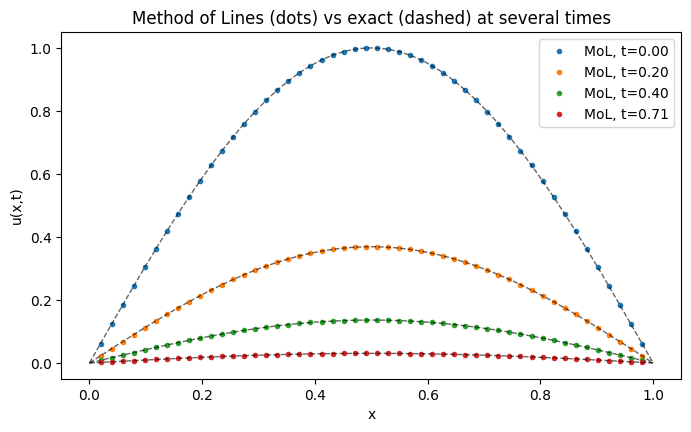

In [3]:
N = 50  # interior grid points
x_grid = np.linspace(0, 1, N + 2)[1:-1]  # exclude the two boundary points (fixed at 0)
dx = x_grid[1] - x_grid[0]

def heat_rhs(t, u):
    u_full = np.concatenate(([0.0], u, [0.0]))  # re-attach boundary conditions
    d2u_dx2 = (u_full[2:] - 2 * u_full[1:-1] + u_full[:-2]) / dx**2
    return alpha * d2u_dx2

u0 = np.sin(np.pi * x_grid)
t_eval = np.linspace(0, 1, 100)
sol_heat = solve_ivp(heat_rhs, (0, 1), u0, t_eval=t_eval, method='RK45', rtol=1e-8, atol=1e-10)

# Compare against exact solution at every grid point and time
X_grid, T_grid = np.meshgrid(x_grid, t_eval)
exact_grid = exact_heat(X_grid, T_grid)
mol_error = np.max(np.abs(sol_heat.y.T - exact_grid))

print(f"Method-of-Lines max error vs exact solution: {mol_error:.2e}")

plt.figure(figsize=(8, 4.5))
for i, t_snap in enumerate([0, 20, 40, 70]):
    plt.plot(x_grid, sol_heat.y[:, t_snap], 'o', markersize=3, label=f"MoL, t={t_eval[t_snap]:.2f}")
    plt.plot(x_plot, exact_heat(x_plot, t_eval[t_snap]), 'k--', linewidth=1, alpha=0.6)
plt.xlabel("x"); plt.ylabel("u(x,t)")
plt.title("Method of Lines (dots) vs exact (dashed) at several times")
plt.legend(); plt.show()


## 4. Modern Method — PINN for the Heat Equation

**What we do here:** train a neural network $\hat{u}_\theta(x, t)$ that takes *two* inputs (position and time) instead of the single time input used in the ODE notebook. We sample random collocation points across the whole $(x, t)$ rectangle and penalize the network whenever $\hat{u}_t - \alpha \hat{u}_{xx} \neq 0$, plus separate loss terms for the initial condition ($t=0$) and the two boundary conditions ($x=0$ and $x=1$).

**What to expect / predict:** we'd predict the PINN converges to a solution that visually matches the smooth, decaying heat profile — this is a well-behaved linear PDE, so we'd expect the PINN to do reasonably well here, similar to how it handled the linear ODE in Part A of the previous notebook, though again with more error than the classical grid-based method.


In [4]:
class PINN2D(nn.Module):
    def __init__(self, hidden=32, layers=4):
        super().__init__()
        modules = [nn.Linear(2, hidden), nn.Tanh()]
        for _ in range(layers - 1):
            modules += [nn.Linear(hidden, hidden), nn.Tanh()]
        modules += [nn.Linear(hidden, 1)]
        self.net = nn.Sequential(*modules)

    def forward(self, x, t):
        return self.net(torch.cat([x, t], dim=1))

pinn_heat = PINN2D().to(device)
optimizer = torch.optim.Adam(pinn_heat.parameters(), lr=1e-3)

N_COLLOC = 2000
x_c = torch.rand(N_COLLOC, 1, requires_grad=True).to(device)
t_c = torch.rand(N_COLLOC, 1, requires_grad=True).to(device)

N_IC = 200
x_ic = torch.rand(N_IC, 1).to(device)
t_ic = torch.zeros(N_IC, 1).to(device)
u_ic_true = torch.sin(np.pi * x_ic)

N_BC = 200
t_bc = torch.rand(N_BC, 1).to(device)
x_bc0 = torch.zeros(N_BC, 1).to(device)
x_bc1 = torch.ones(N_BC, 1).to(device)

def physics_loss_heat():
    u = pinn_heat(x_c, t_c)
    u_t = torch.autograd.grad(u, t_c, torch.ones_like(u), create_graph=True)[0]
    u_x = torch.autograd.grad(u, x_c, torch.ones_like(u), create_graph=True)[0]
    u_xx = torch.autograd.grad(u_x, x_c, torch.ones_like(u_x), create_graph=True)[0]
    residual = u_t - alpha * u_xx
    return torch.mean(residual**2)

def ic_loss_heat():
    u_pred = pinn_heat(x_ic, t_ic)
    return torch.mean((u_pred - u_ic_true)**2)

def bc_loss_heat():
    u0 = pinn_heat(x_bc0, t_bc)
    u1 = pinn_heat(x_bc1, t_bc)
    return torch.mean(u0**2) + torch.mean(u1**2)

EPOCHS = 5000
history = []
for epoch in range(EPOCHS):
    optimizer.zero_grad()
    loss = physics_loss_heat() + 10 * ic_loss_heat() + 10 * bc_loss_heat()
    loss.backward()
    optimizer.step()
    history.append(loss.item())
    if epoch % 500 == 0:
        print(f"epoch {epoch:5d}  loss = {loss.item():.6f}")

print(f"Final loss: {history[-1]:.6f}")


epoch     0  loss = 6.035495


epoch   500  loss = 0.010503


epoch  1000  loss = 0.002176


epoch  1500  loss = 0.001346


epoch  2000  loss = 0.000978


...

epoch  3000  loss = 0.000651


epoch  3500  loss = 0.000531


epoch  4000  loss = 0.000448


epoch  4500  loss = 0.000411


Final loss: 0.000339


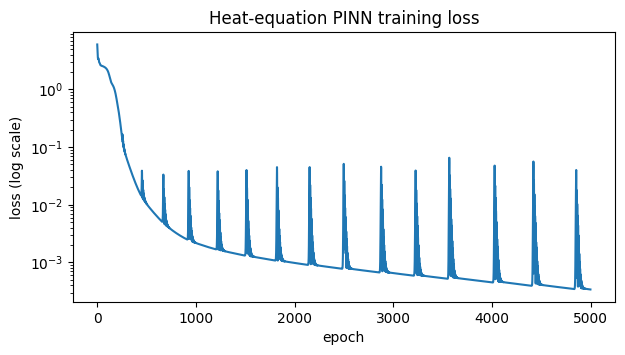

In [5]:
plt.figure(figsize=(7, 3.5))
plt.plot(history)
plt.yscale('log')
plt.xlabel("epoch"); plt.ylabel("loss (log scale)")
plt.title("Heat-equation PINN training loss")
plt.show()


## 5. Comparing All Three: Exact vs. Method of Lines vs. PINN

**What we do here:** evaluate the trained PINN across the full $(x,t)$ grid and compare it against the exact solution and the Method-of-Lines result.

**What to expect / predict:** we'd expect the Method of Lines to again be essentially exact, and the PINN to visibly reproduce the correct decaying-sine shape with a moderate error — a similar pattern to Part A of the ODE notebook, just now in two dimensions.


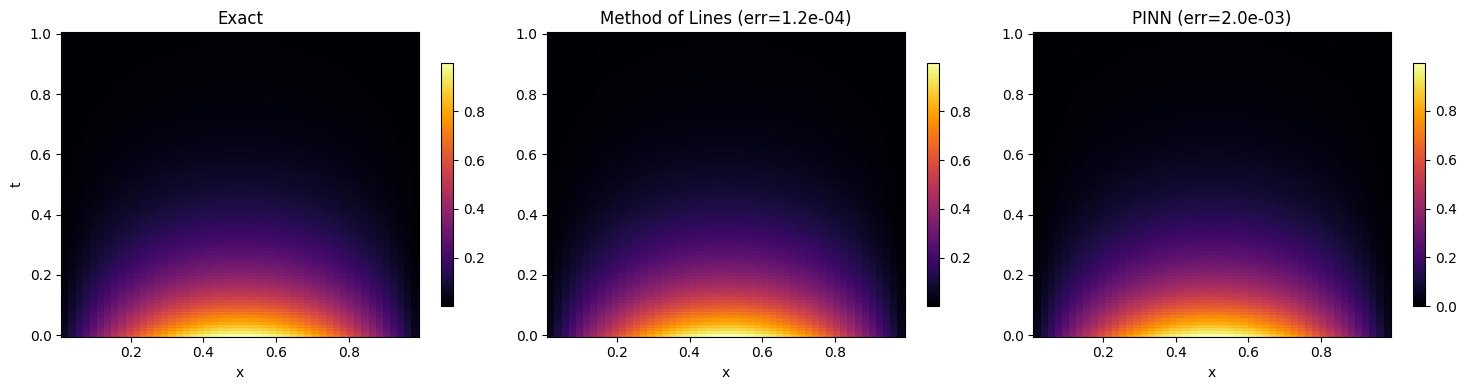

Method of Lines max error : 1.16e-04
PINN max error            : 1.98e-03


In [6]:
pinn_heat.eval()
x_test = torch.tensor(X_grid.flatten(), dtype=torch.float32).view(-1, 1).to(device)
t_test = torch.tensor(T_grid.flatten(), dtype=torch.float32).view(-1, 1).to(device)
with torch.no_grad():
    u_pinn_flat = pinn_heat(x_test, t_test).cpu().numpy().flatten()
u_pinn_grid = u_pinn_flat.reshape(X_grid.shape)

pinn_heat_error = np.max(np.abs(u_pinn_grid - exact_grid))

fig, ax = plt.subplots(1, 3, figsize=(15, 4))
im0 = ax[0].pcolormesh(x_grid, t_eval, exact_grid, shading='auto', cmap='inferno')
ax[0].set_title("Exact"); ax[0].set_xlabel("x"); ax[0].set_ylabel("t")
im1 = ax[1].pcolormesh(x_grid, t_eval, sol_heat.y.T, shading='auto', cmap='inferno')
ax[1].set_title(f"Method of Lines (err={mol_error:.1e})"); ax[1].set_xlabel("x")
im2 = ax[2].pcolormesh(x_grid, t_eval, u_pinn_grid, shading='auto', cmap='inferno')
ax[2].set_title(f"PINN (err={pinn_heat_error:.1e})"); ax[2].set_xlabel("x")
for im, a in zip([im0, im1, im2], ax):
    fig.colorbar(im, ax=a, shrink=0.8)
plt.tight_layout(); plt.show()

print(f"Method of Lines max error : {mol_error:.2e}")
print(f"PINN max error            : {pinn_heat_error:.2e}")


---
# Part B — Viscous Burgers' Equation (Nonlinear PDE)

## 6. The Problem

**What we're solving:** Burgers' equation, a nonlinear PDE that models phenomena like traffic flow and shock waves in fluids — famous in the PINN literature because it's the actual benchmark problem from the original 2019 Physics-Informed Neural Networks paper:

$$\frac{\partial u}{\partial t} + u\frac{\partial u}{\partial x} = \nu \frac{\partial^2 u}{\partial x^2}, \qquad x \in [-1, 1],\ t \in [0, 1]$$
$$u(x, 0) = -\sin(\pi x), \qquad u(-1, t) = u(1, t) = 0, \qquad \nu = \frac{0.01}{\pi}$$

**What makes this hard:** the small viscosity $\nu$ means the two halves of the initial wave (moving toward each other) steepen into a **sharp, near-vertical front** around $x=0$ as $t$ increases, similar to a shock wave. This is a genuinely difficult test — coarse classical grids and basic PINNs can both struggle to resolve a feature that sharp.

**What to expect / predict:** we should see the smooth $-\sin(\pi x)$ curve progressively steepen into a thin, cliff-like transition near the center as time advances, rather than smoothly flattening out like the heat equation did.


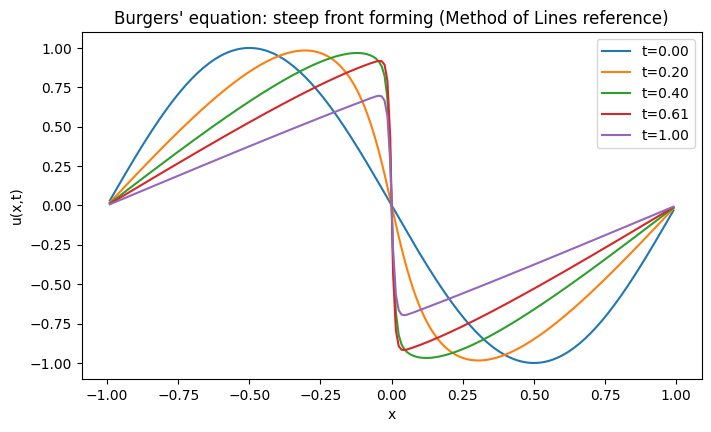

In [7]:
nu = 0.01 / np.pi

def burgers_rhs(t, u, x_grid, dx):
    u_full = np.concatenate(([0.0], u, [0.0]))
    u_xx = (u_full[2:] - 2 * u_full[1:-1] + u_full[:-2]) / dx**2
    # Upwind scheme for the nonlinear advection term -- central differences alone
    # go unstable near the steep front this equation develops.
    u_x_backward = (u_full[1:-1] - u_full[:-2]) / dx
    u_x_forward = (u_full[2:] - u_full[1:-1]) / dx
    u_x_upwind = np.where(u > 0, u_x_backward, u_x_forward)
    return -u * u_x_upwind + nu * u_xx

N_burgers = 200
x_grid_b = np.linspace(-1, 1, N_burgers + 2)[1:-1]
dx_b = x_grid_b[1] - x_grid_b[0]
u0_b = -np.sin(np.pi * x_grid_b)

t_eval_b = np.linspace(0, 1, 100)
sol_burgers = solve_ivp(
    burgers_rhs, (0, 1), u0_b, t_eval=t_eval_b, method='BDF',
    args=(x_grid_b, dx_b), rtol=1e-7, atol=1e-9
)
u_ref_grid = sol_burgers.y.T  # shape (time, space) -- this is our high-resolution reference

plt.figure(figsize=(8, 4.5))
for t_snap in [0, 20, 40, 60, 99]:
    plt.plot(x_grid_b, u_ref_grid[t_snap], label=f"t={t_eval_b[t_snap]:.2f}")
plt.xlabel("x"); plt.ylabel("u(x,t)")
plt.title("Burgers' equation: steep front forming (Method of Lines reference)")
plt.legend(); plt.show()


## 7. PINN for Burgers' Equation

**What we do here:** same PINN architecture, now trained against the nonlinear residual $\hat{u}_t + \hat{u}\hat{u}_x - \nu\hat{u}_{xx}$. We use more collocation points and a larger network than the heat-equation PINN, since capturing a sharp near-shock front is a much harder function to represent than a smooth decaying sine wave.

**What to expect / predict:** we'd predict the PINN reproduces the overall wave shape reasonably well away from the center, but shows its largest errors right around the steep front at $x \approx 0$ — plain PINNs are well known in the literature to have exactly this difficulty, since a basic fully-connected network without adaptive point sampling near the front has to "spend" the same representational effort everywhere in the domain, including regions where nothing interesting happens.


In [8]:
pinn_burgers = PINN2D(hidden=64, layers=5).to(device)
optimizer_b = torch.optim.Adam(pinn_burgers.parameters(), lr=1e-3)
scheduler_b = torch.optim.lr_scheduler.StepLR(optimizer_b, step_size=4000, gamma=0.5)

N_COLLOC_B = 4000
x_c_b = (torch.rand(N_COLLOC_B, 1) * 2 - 1).to(device).requires_grad_(True)
t_c_b = torch.rand(N_COLLOC_B, 1).to(device).requires_grad_(True)

N_IC_B = 300
x_ic_b = (torch.rand(N_IC_B, 1) * 2 - 1).to(device)
t_ic_b = torch.zeros(N_IC_B, 1).to(device)
u_ic_true_b = -torch.sin(np.pi * x_ic_b)

N_BC_B = 300
t_bc_b = torch.rand(N_BC_B, 1).to(device)
x_bc_neg1 = -torch.ones(N_BC_B, 1).to(device)
x_bc_pos1 = torch.ones(N_BC_B, 1).to(device)

def physics_loss_burgers():
    u = pinn_burgers(x_c_b, t_c_b)
    u_t = torch.autograd.grad(u, t_c_b, torch.ones_like(u), create_graph=True)[0]
    u_x = torch.autograd.grad(u, x_c_b, torch.ones_like(u), create_graph=True)[0]
    u_xx = torch.autograd.grad(u_x, x_c_b, torch.ones_like(u_x), create_graph=True)[0]
    residual = u_t + u * u_x - nu * u_xx
    return torch.mean(residual**2)

def ic_loss_burgers():
    u_pred = pinn_burgers(x_ic_b, t_ic_b)
    return torch.mean((u_pred - u_ic_true_b)**2)

def bc_loss_burgers():
    u_neg1 = pinn_burgers(x_bc_neg1, t_bc_b)
    u_pos1 = pinn_burgers(x_bc_pos1, t_bc_b)
    return torch.mean(u_neg1**2) + torch.mean(u_pos1**2)

EPOCHS_B = 10000
history_b = []
for epoch in range(EPOCHS_B):
    optimizer_b.zero_grad()
    loss = physics_loss_burgers() + 10 * ic_loss_burgers() + 10 * bc_loss_burgers()
    loss.backward()
    optimizer_b.step()
    scheduler_b.step()
    history_b.append(loss.item())
    if epoch % 1000 == 0:
        print(f"epoch {epoch:5d}  loss = {loss.item():.6f}")

print(f"Final loss: {history_b[-1]:.6f}")


epoch     0  loss = 4.768726


epoch  1000  loss = 0.272644


epoch  2000  loss = 0.247147


epoch  3000  loss = 0.220204


epoch  4000  loss = 0.206617


...

epoch  6000  loss = 0.174999


epoch  7000  loss = 0.159406


epoch  8000  loss = 0.119046


epoch  9000  loss = 0.040653


Final loss: 0.022142


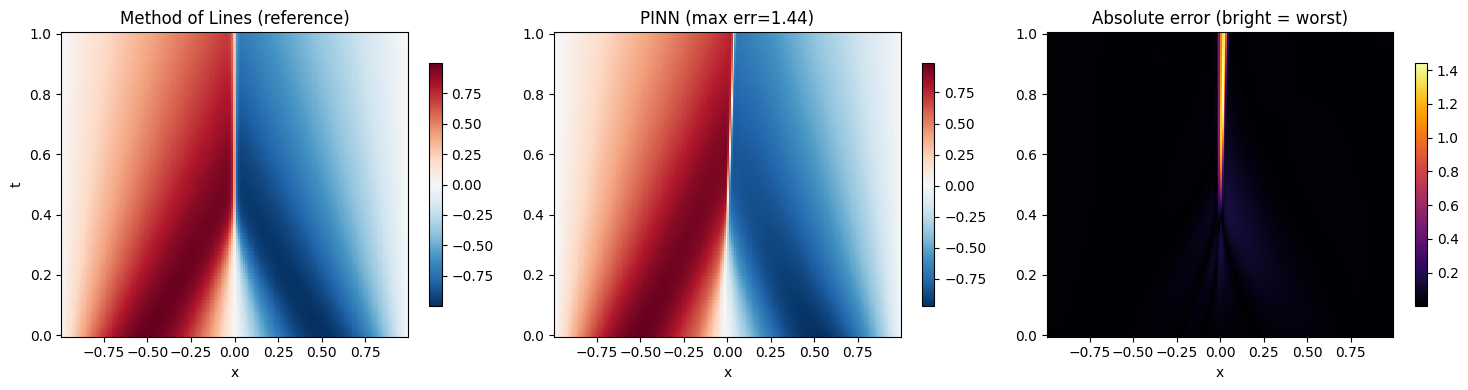

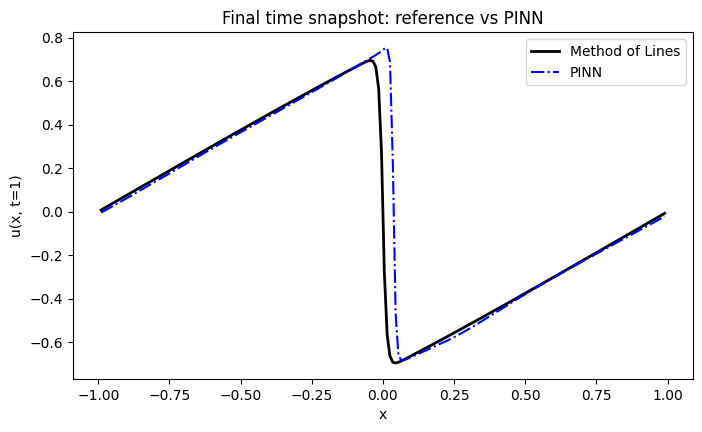

PINN max error vs reference : 1.4441
PINN MSE vs reference       : 0.010659


In [9]:
pinn_burgers.eval()
X_grid_b, T_grid_b = np.meshgrid(x_grid_b, t_eval_b)
x_test_b = torch.tensor(X_grid_b.flatten(), dtype=torch.float32).view(-1, 1).to(device)
t_test_b = torch.tensor(T_grid_b.flatten(), dtype=torch.float32).view(-1, 1).to(device)
with torch.no_grad():
    u_pinn_b_flat = pinn_burgers(x_test_b, t_test_b).cpu().numpy().flatten()
u_pinn_b_grid = u_pinn_b_flat.reshape(X_grid_b.shape)

burgers_error = np.max(np.abs(u_pinn_b_grid - u_ref_grid))
burgers_mse = np.mean((u_pinn_b_grid - u_ref_grid)**2)

fig, ax = plt.subplots(1, 3, figsize=(15, 4))
im0 = ax[0].pcolormesh(x_grid_b, t_eval_b, u_ref_grid, shading='auto', cmap='RdBu_r')
ax[0].set_title("Method of Lines (reference)"); ax[0].set_xlabel("x"); ax[0].set_ylabel("t")
im1 = ax[1].pcolormesh(x_grid_b, t_eval_b, u_pinn_b_grid, shading='auto', cmap='RdBu_r')
ax[1].set_title(f"PINN (max err={burgers_error:.2f})"); ax[1].set_xlabel("x")
im2 = ax[2].pcolormesh(x_grid_b, t_eval_b, np.abs(u_pinn_b_grid - u_ref_grid), shading='auto', cmap='inferno')
ax[2].set_title("Absolute error (bright = worst)"); ax[2].set_xlabel("x")
for im, a in zip([im0, im1, im2], ax):
    fig.colorbar(im, ax=a, shrink=0.8)
plt.tight_layout(); plt.show()

plt.figure(figsize=(8, 4.5))
final_t_idx = -1
plt.plot(x_grid_b, u_ref_grid[final_t_idx], 'k-', label="Method of Lines", linewidth=2)
plt.plot(x_grid_b, u_pinn_b_grid[final_t_idx], 'b-.', label="PINN")
plt.xlabel("x"); plt.ylabel("u(x, t=1)")
plt.title("Final time snapshot: reference vs PINN")
plt.legend(); plt.show()

print(f"PINN max error vs reference : {burgers_error:.4f}")
print(f"PINN MSE vs reference       : {burgers_mse:.6f}")


## 8. Summary & Takeaways

**Part A (linear heat equation, has exact solution):**
- The Method of Lines reproduced the exact solution almost perfectly.
- The PINN learned the correct smooth, decaying shape with moderate error — consistent with how it performed on the linear ODE in the previous notebook.

**Part B (nonlinear Burgers' equation, steep front):**
- The Method of Lines (with an upwind scheme to stay stable near the front) tracked the sharpening wave correctly and served as our reference.
- The PINN captured the overall wave shape but showed its largest errors concentrated right at the steep front — the exact region the underlying physics literature flags as the hard part of this benchmark.

**When to actually use which, in practice:**
- For PDEs on simple, fixed, low-dimensional domains like these — **use classical grid-based methods.** They're faster, more accurate, and the theory behind their error and stability is extremely well understood.
- PINNs earn their place on problems where a grid becomes impractical: very high-dimensional PDEs (grids scale explosively with dimension, PINNs don't), irregular or evolving geometries, or "inverse" problems where you want to simultaneously infer an unknown physical parameter (like $\nu$ here) from sparse, noisy measurements.

**Honest limitation to state clearly:** this notebook uses a basic PINN setup (uniform random collocation points, fixed loss weights). Research-grade PINN implementations for sharp-front problems like Burgers' equation typically add adaptive collocation-point refinement near the front, loss-weighting schedules, or domain decomposition — techniques that would close the gap seen in Part B. This notebook demonstrates the core method and gives an honest read of its out-of-the-box limitations, not a fully tuned research implementation.
